In [1]:
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity
from ExistingAlgorithms.Area import area
from AutoencoderAPI.autoencoderBayesianGaussianMixture import autoencoder_bayesianGaussianMixture
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture

from AutoencoderAPI.loadAutoencoder import loadAutoencoder
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture

In [2]:
signal_size = 250
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

In [3]:
def plot_silhouette_gaussianMixture(X_low_train, X_low_test, component):

    def gaussian_function(x, mean, variance):
        return (2*np.pi*variance)**(-1/2) * np.exp(-(x - mean)**2/(2*variance))

    #component = 25 
    gmm = GaussianMixture(n_components=component, tol=1e-5, max_iter=300, means_init=np.linspace(min(X_low_train), max(X_low_train), component)).fit(X_low_train)
    #gmm = GaussianMixture(n_components=component, tol=1e-5, max_iter=300, init_params="kmeans").fit(X_low_train)

    mean_ = gmm.means_
    covariance_ = gmm.covariances_
    labels = gmm.predict(X_low_test)
    bins = np.linspace(min(X_low_train), max(X_low_train), 5000).reshape(-1)

    clusters_low = []
    for label in np.unique(labels):
        condition = labels == label
        clusters_low.append(X_low_test.flatten()[condition])
        #condition.append(condition)

    x = np.linspace(min(X_low_train), max(X_low_train), 1000)
    plt.figure(figsize=(10,5))
    for index, mean_value in enumerate(mean_):
        plt.plot(x, gaussian_function(x, mean_value, covariance_[index]), linewidth=1.1)
    for cluster in clusters_low:
        plt.hist(cluster, bins=bins)
    plt.vlines(mean_, 0, 3, colors="k", linewidth=0.5)

c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\mixture\_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


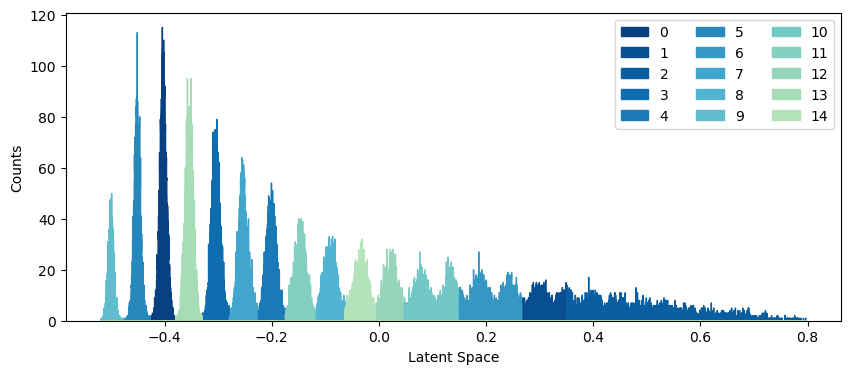

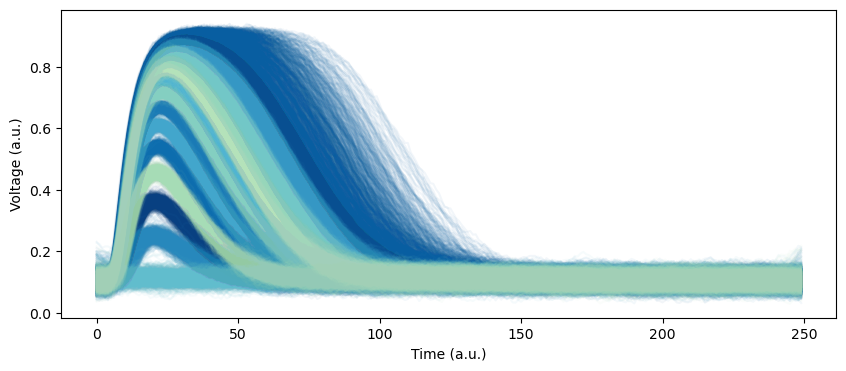

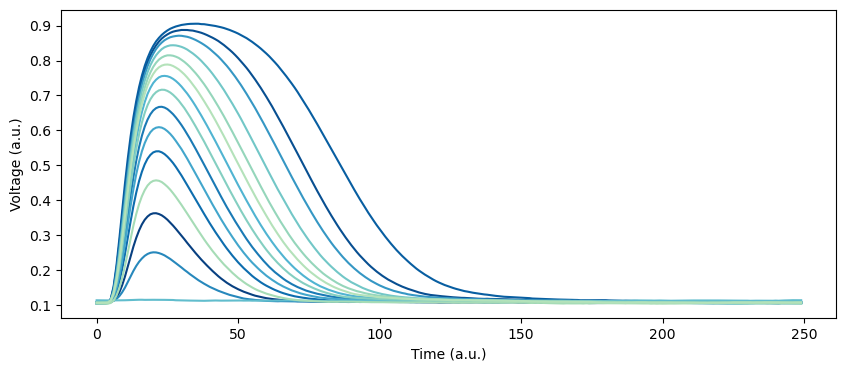

In [4]:
agm = autoencoder_bayesianGaussianMixture('AutoencoderLog/run-2023-10-10-09-19/fold 0')
agm.fit(np.copy(X_train), 
        plot_cluster=True,
        plot_traces=True,
        plot_traces_average=True,
        cluster_max = 30,
        filter_input=True, 
        flip=True)

Clusters:   0%|          | 0/21 [00:00<?, ?it/s]

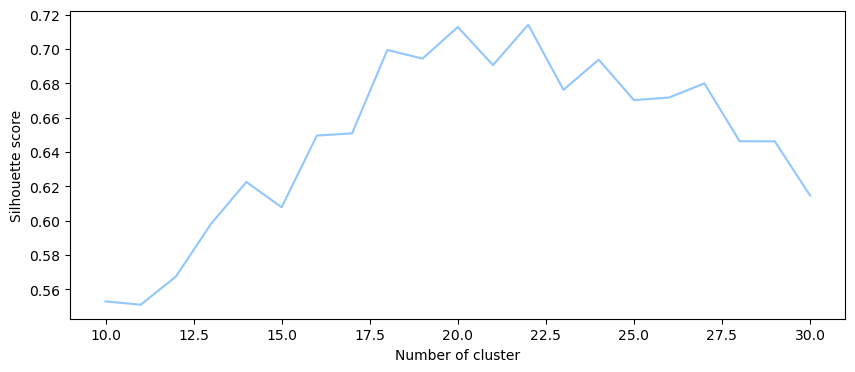

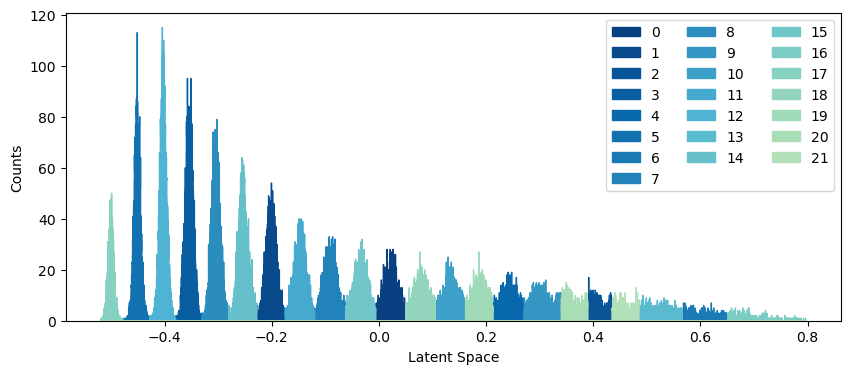

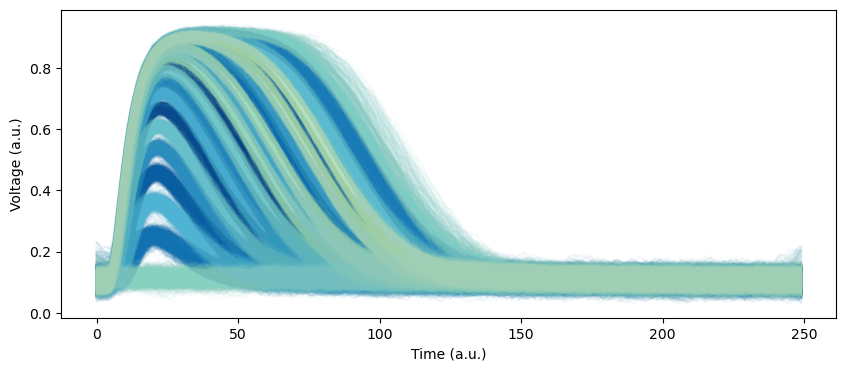

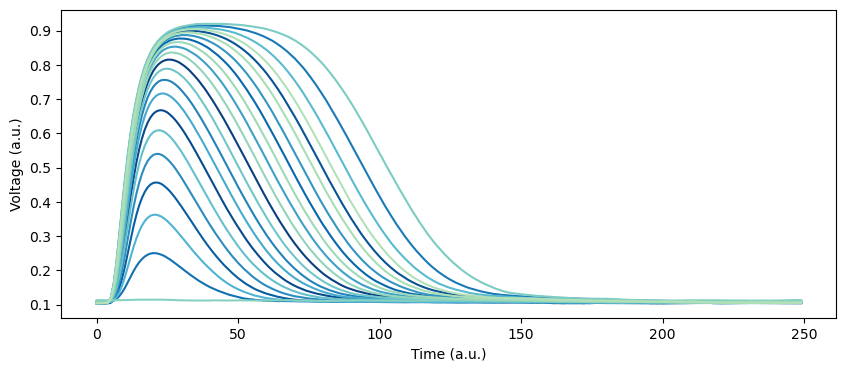

In [5]:
agm = autoencoder_gaussianMixture('AutoencoderLog/run-2023-10-10-09-19/fold 0')
agm.fit(np.copy(X_train), 
        plot_silhouette=True,
        plot_cluster=True,
        plot_traces=True,
        plot_traces_average=True,
        cluster_interval = [10,30],
        filter_input=True, 
        flip=True)